<a href="https://colab.research.google.com/github/tiendinh-hcmut/ML-Food-Ingredient-Classification/blob/main/food_ingredient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install required libraries
!pip install datasets pandas matplotlib seaborn missingno -q

from datasets import load_dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import io
from PIL import Image

In [ ]:
# 2. Load the dataset and check its basic structure
print("Loading the dataset from HuggingFace...")
dataset = load_dataset("Scuccorese/food-ingredients-dataset")

# Convert the 'train' split into a Pandas DataFrame for easier analysis
df = dataset['train'].to_pandas()

Loading the dataset from HuggingFace...


In [ ]:

# Display the first 5 rows to see what the data looks like
print("\n--- First 5 rows of the dataset ---")
display(df.head())

# Check the dimensions (number of rows and columns)
print("\n--- Data Structure ---")
print(f"Number of rows (Total images): {df.shape[0]}")
print(f"Number of columns (Features): {df.shape[1]}")

# Display column names and their data types
print("\n--- Columns and Data Types ---")
df.info()

Loading the dataset from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/407 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/367M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/476M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/484M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6676 [00:00<?, ? examples/s]


--- First 5 rows of the dataset ---


,category,subcategory,ingredient,image
0,vegetables,leafy,spinach,{'bytes': b'RIFF\x9a\xbf\x01\x00WEBPVP8 \x8e\x...
1,vegetables,leafy,spinach,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
2,vegetables,leafy,spinach,{'bytes': b'\xff\xd8\xff\xe1s\xa9Exif\x00\x00I...
3,vegetables,leafy,spinach,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
4,vegetables,leafy,spinach,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...



--- Data Structure ---
Number of rows (Total images): 6676
Number of columns (Features): 4

--- Columns and Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6676 entries, 0 to 6675
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   category     6676 non-null   object
 1   subcategory  6676 non-null   object
 2   ingredient   6676 non-null   object
 3   image        6676 non-null   object
dtypes: object(4)
memory usage: 208.8+ KB


In [ ]:
# 3. Count unique values for hierarchical levels (excluding the image column)
print("--- Number of Unique Classes ---")
columns_to_count = ['category', 'subcategory', 'ingredient']
print(df[columns_to_count].nunique())

--- Number of Unique Classes ---
category        12
subcategory     28
ingredient     316
dtype: int64


--- Missing Values Count ---
category       0
subcategory    0
ingredient     0
image          0
dtype: int64

--- Missing Values Percentage (%) ---
category       0.0
subcategory    0.0
ingredient     0.0
image          0.0
dtype: float64


<Figure size 1000x500 with 0 Axes>

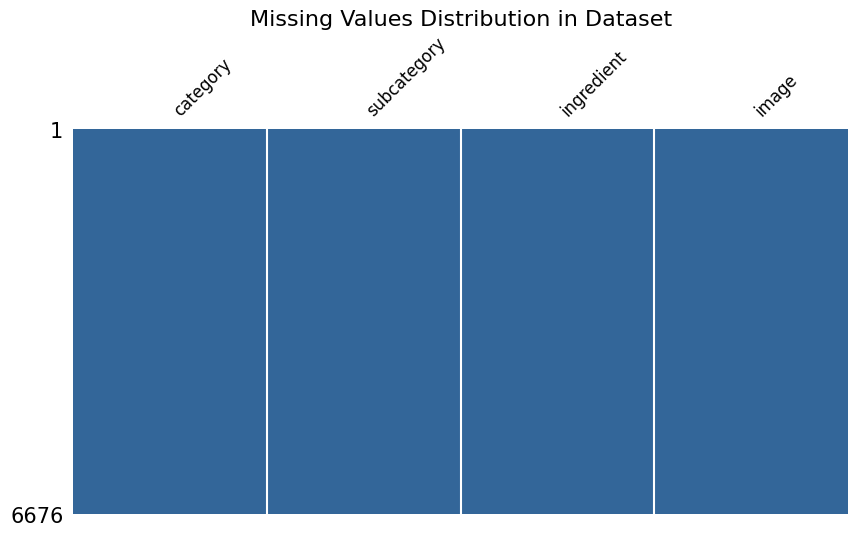

In [ ]:
# 4 & 5. Check and visualize Missing Values
print("--- Missing Values Count ---")
missing_counts = df.isnull().sum()
print(missing_counts)

print("\n--- Missing Values Percentage (%) ---")
print((df.isnull().mean() * 100).round(2))

# Visualize
plt.figure(figsize=(10, 5))
msno.matrix(df, figsize=(10, 5), sparkline=False, fontsize=12, color=(0.2, 0.4, 0.6))
plt.title("Missing Values Distribution in Dataset", fontsize=16)
plt.show()

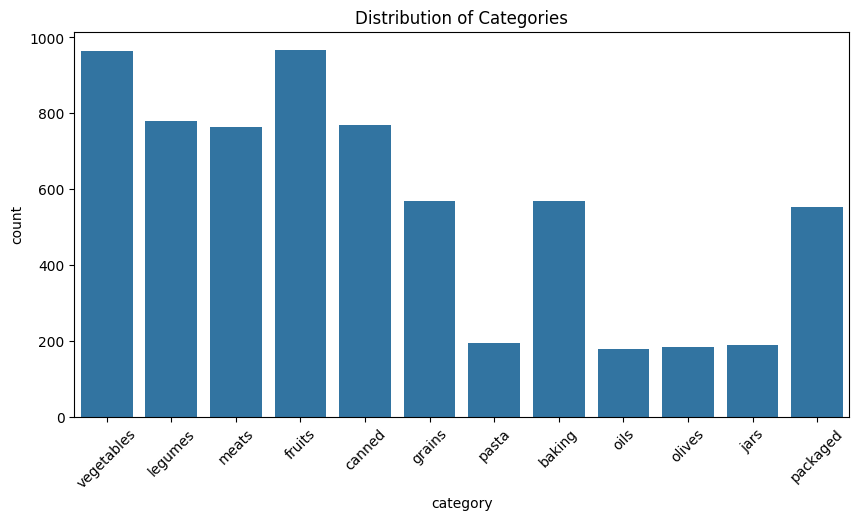

In [ ]:
# EDA part 2
# Category Distribution (countplot)
plt.figure(figsize=(10,5))
sns.countplot(x='category', data=df)

plt.xticks(rotation=45)
plt.title("Distribution of Categories")
plt.show()

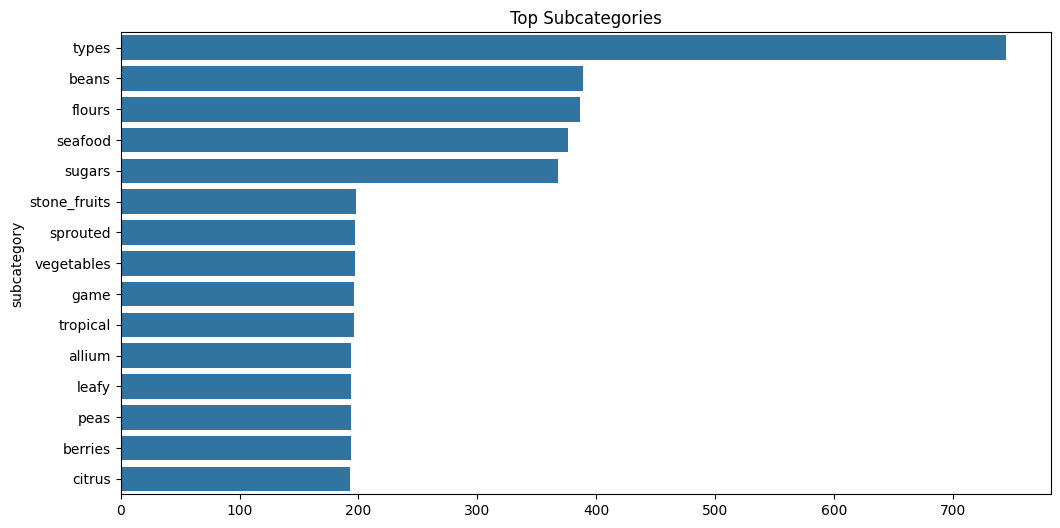

In [ ]:
# Subcategory Distribution
plt.figure(figsize=(12,6))

top_sub = df['subcategory'].value_counts().head(15)

sns.barplot(x=top_sub.values, y=top_sub.index)

plt.title("Top Subcategories")
plt.show()

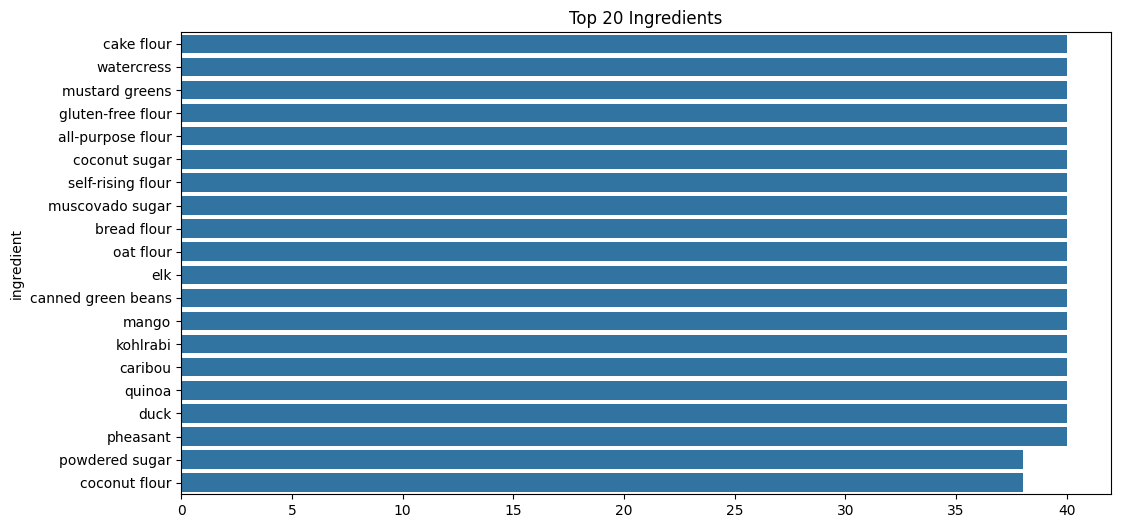

In [ ]:
# Ingredient Distribution
plt.figure(figsize=(12,6))

top_ing = df['ingredient'].value_counts().head(20)

sns.barplot(x=top_ing.values, y=top_ing.index)

plt.title("Top 20 Ingredients")
plt.show()

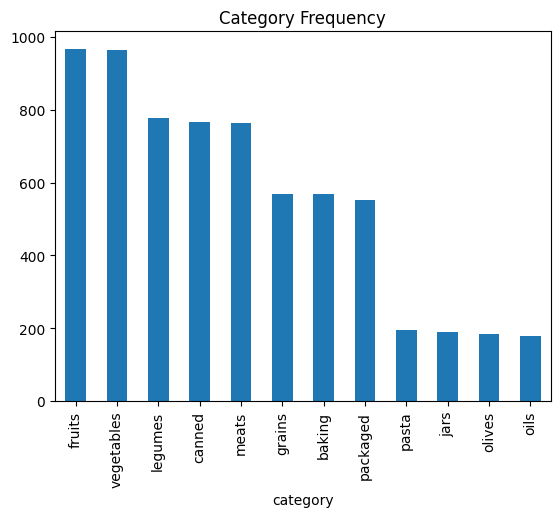

In [ ]:
# Histogram
df['category'].value_counts().plot(kind='bar')
plt.title("Category Frequency")
plt.show()

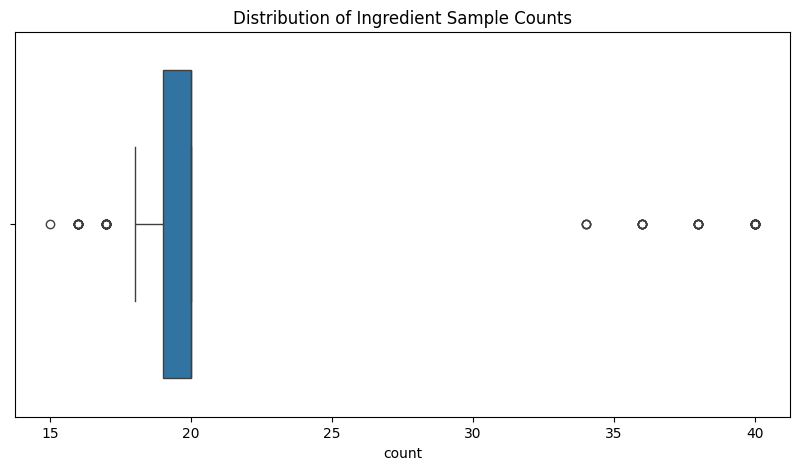

In [ ]:
# Outliers
ingredient_counts = df['ingredient'].value_counts()

plt.figure(figsize=(10,5))
sns.boxplot(x=ingredient_counts)

plt.title("Distribution of Ingredient Sample Counts")
plt.show()

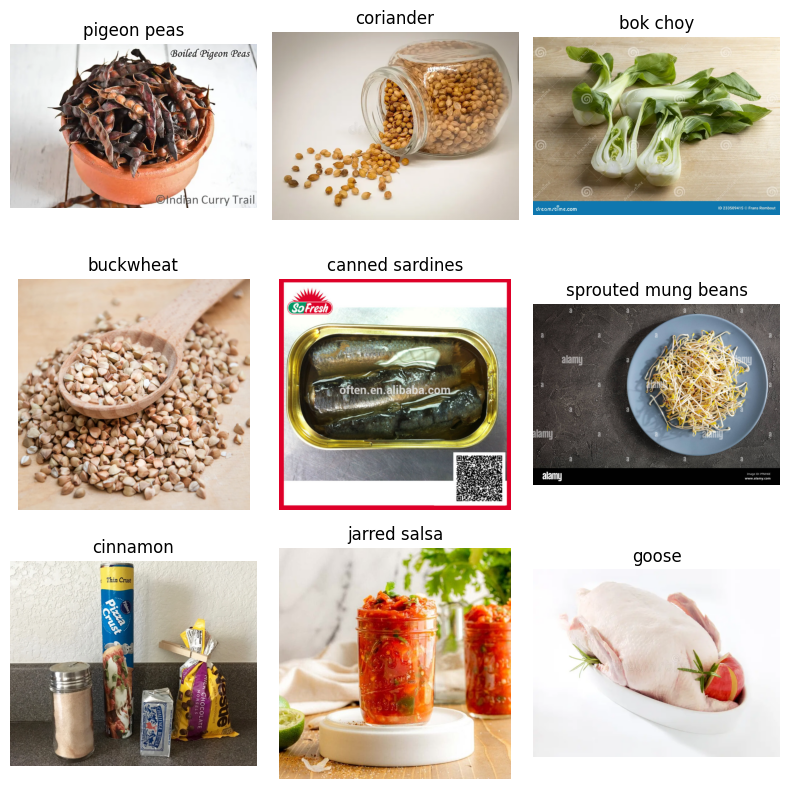

In [ ]:
sample = df.sample(9)

plt.figure(figsize=(8,8))

for i, (_, row) in enumerate(sample.iterrows()):
    plt.subplot(3,3,i+1)

    # Extract image bytes from the dictionary and open as PIL Image
    image_bytes = row["image"]["bytes"]
    img = Image.open(io.BytesIO(image_bytes))

    plt.imshow(img)
    plt.title(row["ingredient"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Function to get image width and height from the dictionary column
def get_image_dimensions(image_dict):
    if image_dict and 'bytes' in image_dict:
        img = Image.open(io.BytesIO(image_dict['bytes']))
        return img.width, img.height
    return None, None

df['width'], df['height'] = zip(*df['image'].apply(get_image_dimensions))

print(df[['width','height']].describe())

             width       height
count  6676.000000  6676.000000
mean   1151.161474  1088.912373
std     642.365283   601.818106
min     173.000000   170.000000
25%     740.000000   626.000000
50%    1000.000000  1000.000000
75%    1500.000000  1313.000000
max    6720.000000  5286.000000


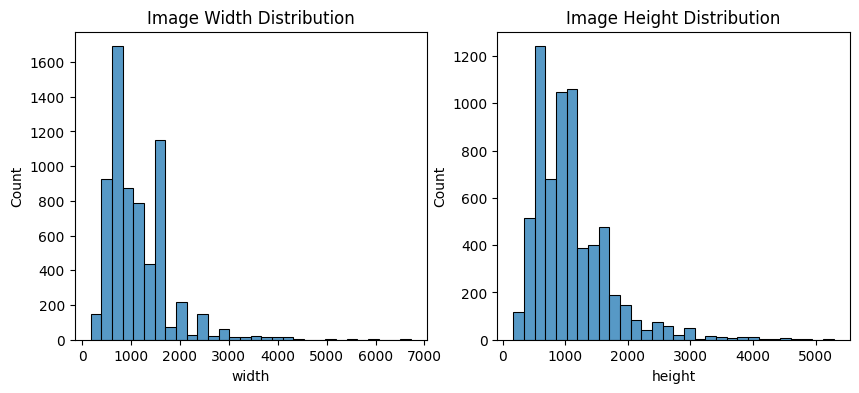

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df["width"], bins=30)
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
sns.histplot(df["height"], bins=30)
plt.title("Image Height Distribution")

plt.show()